# 04 — Clustering (Phân cụm) — v2 với Optuna

**Bối cảnh:** đề là **clustering** unsupervised. Notebook này thực hiện toàn bộ phần model: tìm k tối ưu (grid + Optuna), fit MiniBatchKMeans, so sánh với GaussianMixture, mô tả + gán nhãn cụm, visualization, demo 10 mẫu test.

**Cải thiện v2:**

| Thay đổi | v1 | v2 | Lý do |
|---|---|---|---|
| K-search range | [3, 20] | **[3, 25]** | Để Optuna có headroom |
| Hyperparam tuning | Grid k only | **+ Optuna 30 trials** trên (k, init, whitening) | Tìm combination tốt hơn grid thuần |
| Whitening | Không | **Có (tunable 0-1)** | Equalize variance giữa SVD dims |

**Input từ `features/`:**
- `X_train_svd.npy`, `X_test_svd.npy` — dense 150D float32 (tăng từ 100 ở stage 3 v2).
- `X_train.npz`, `X_test.npz` — sparse 25-30k cho cluster profiling.
- `transformers.joblib`, `meta.json`, `feature_names.txt`.

**Output trong `models/`:**
- `kmeans_best.joblib`, `gmm_best.joblib` — model đã fit.
- `optuna_study.joblib` — MỚI: Optuna study object.
- `labels_train.npy`, `labels_test.npy` — nhãn cụm 545k + 61k.
- `cluster_profiles.csv`, `cluster_names.json`.
- `k_search_metrics.csv`, `gmm_bic_aic.csv`, `clustering_summary.json`.
- `demo_10_test_samples.csv` (10 mẫu demo theo template báo cáo).

**Pipeline:**

1. Load artifact + L2-normalize SVD.
2. K-search grid `k ∈ [3, 25]` → 4 metric curves (inertia/silhouette/DB/CH).
3. **NEW: Optuna fine-tune** (k, init, whitening_strength) qua 30 trials TPE → chốt final params.
4. Fit final MiniBatchKMeans với Optuna-best params → labels train + test.
5. GMM compare (BIC/AIC scan k ∈ [3, 15]).
6. Cluster profiling chunked.
7. Top TF-IDF tokens per cluster.
8. Gán nhãn cụm tự động.
9. t-SNE 2D stratified sample 8k.
10. Demo 10 mẫu test.
11. Lưu artifact.

In [1]:
from pathlib import Path
from collections import Counter
import json
import sys
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import sparse

from sklearn.cluster import MiniBatchKMeans
from sklearn.manifold import TSNE
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import normalize

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

ROOT = Path.cwd().parent
CLEAN = ROOT / 'clean_data'
FEATURES = ROOT / 'features'
MODELS = ROOT / 'models'
MODELS.mkdir(exist_ok=True)
FIG_DIR = ROOT / 'figures'
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'DejaVu Sans'

RANDOM_STATE = 42
K_RANGE = list(range(3, 26))               # mở rộng từ [3,20] → [3,25]
GMM_K_RANGE = list(range(3, 16))
GMM_SAMPLE_SIZE = 30_000
METRIC_SAMPLE_SIZE = 30_000
TSNE_SAMPLE_SIZE = 8_000
DEMO_N_TEST = 10
OPTUNA_N_TRIALS = 30                       # số trials Optuna study
PROFILE_CHUNK = 50_000

print(f"Models output dir: {MODELS}")

Models output dir: D:\Documents\School\Ki_6\KHDL\09 - Dự đoán mức lương kỳ vọng dựa trên bản mô tả công việc (Job Description)\models


## 1. Load artifact + L2-normalize SVD

Load tất cả output từ stage 3 (`features/`). Sau đó **L2-normalize** từng row của ma trận SVD — biến K-Means thành tương đương cosine clustering trên TF-IDF (cosine là metric chuẩn cho text data).

In [2]:
print("Load artifact từ features/...")
X_train_svd = np.load(FEATURES / 'X_train_svd.npy')
X_test_svd = np.load(FEATURES / 'X_test_svd.npy')
X_train_sp = sparse.load_npz(FEATURES / 'X_train.npz')
X_test_sp = sparse.load_npz(FEATURES / 'X_test.npz')
meta = json.loads((FEATURES / 'meta.json').read_text(encoding='utf-8'))
feature_names = (FEATURES / 'feature_names.txt').read_text(encoding='utf-8').splitlines()
transformers = joblib.load(FEATURES / 'transformers.joblib')

print(f"  X_train_svd: {X_train_svd.shape} ({X_train_svd.nbytes/1e6:.1f} MB dense)")
print(f"  X_test_svd : {X_test_svd.shape}")
print(f"  X_train sparse: {X_train_sp.shape} ({X_train_sp.nnz:,} nnz)")
print(f"  X_test sparse : {X_test_sp.shape}")
print(f"  feature_names : {len(feature_names):,}")
print(f"  SVD variance giữ: {meta['svd_explained_variance_ratio_total']*100:.2f}%")

X_train_svd_n = normalize(X_train_svd, norm='l2').astype(np.float32)
X_test_svd_n = normalize(X_test_svd, norm='l2').astype(np.float32)
print(f"\nĐã L2-normalize SVD features (norm row = 1) → K-Means ≈ cosine clustering.")

Load artifact từ features/...


  X_train_svd: (545480, 150) (327.3 MB dense)
  X_test_svd : (60606, 150)
  X_train sparse: (545480, 25664) (101,657,836 nnz)
  X_test sparse : (60606, 25664)
  feature_names : 25,664
  SVD variance giữ: 77.72%



Đã L2-normalize SVD features (norm row = 1) → K-Means ≈ cosine clustering.


## 2. K-search — tìm số cụm tối ưu cho MiniBatchKMeans

Loop `k ∈ [3, 20]`, fit `MiniBatchKMeans(batch_size=4096)` trên X_train_svd_n (545k × 100). Với mỗi k, tính 4 metric:

- **Inertia** (sum of squared distances) → curve có khuỷu (elbow).
- **Silhouette score** (cao = tách rõ) trên sample 30k (O(n²) không scale full).
- **Davies-Bouldin index** (thấp = tốt) — tỉ lệ within/between scatter.
- **Calinski-Harabasz index** (cao = tốt).

Chọn k cuối theo silhouette (metric chuẩn nhất cho cluster quality).

In [3]:
results = []
for k in K_RANGE:
    t0 = time.time()
    km = MiniBatchKMeans(n_clusters=k, random_state=RANDOM_STATE,
                         batch_size=4096, max_iter=100, n_init=3)
    labels = km.fit_predict(X_train_svd_n)

    rng = np.random.RandomState(RANDOM_STATE)
    idx = rng.choice(len(labels), METRIC_SAMPLE_SIZE, replace=False)
    sX, sL = X_train_svd_n[idx], labels[idx]

    sil = silhouette_score(sX, sL, random_state=RANDOM_STATE)
    db = davies_bouldin_score(sX, sL)
    ch = calinski_harabasz_score(sX, sL)

    elapsed = time.time() - t0
    results.append({
        'k': k,
        'inertia': float(km.inertia_),
        'silhouette': float(sil),
        'davies_bouldin': float(db),
        'calinski_harabasz': float(ch),
        'fit_time_sec': round(elapsed, 1),
    })
    print(f"  k={k:>2} | inertia={km.inertia_:>10.0f} | sil={sil:+.4f} | "
          f"DB={db:.3f} | CH={ch:>8.0f} | {elapsed:.1f}s")

results_df = pd.DataFrame(results)
results_df.to_csv(MODELS / 'k_search_metrics.csv', index=False)
print(f"\nĐã lưu: {MODELS / 'k_search_metrics.csv'}")

  k= 3 | inertia=    328228 | sil=+0.1140 | DB=2.467 | CH=    3872 | 12.3s


  k= 4 | inertia=    311205 | sil=+0.1053 | DB=2.604 | CH=    3273 | 9.7s


  k= 5 | inertia=    288408 | sil=+0.1278 | DB=2.205 | CH=    3249 | 10.2s


  k= 6 | inertia=    281392 | sil=+0.1148 | DB=2.231 | CH=    2821 | 9.9s


  k= 7 | inertia=    272862 | sil=+0.0983 | DB=2.440 | CH=    2577 | 10.4s


...

  k=21 | inertia=    228158 | sil=+0.0963 | DB=2.610 | CH=    1219 | 9.8s


  k=22 | inertia=    226453 | sil=+0.0959 | DB=2.608 | CH=    1183 | 9.8s


  k=23 | inertia=    224900 | sil=+0.0962 | DB=2.587 | CH=    1146 | 9.7s


  k=24 | inertia=    222736 | sil=+0.0941 | DB=2.597 | CH=    1119 | 9.9s


  k=25 | inertia=    221590 | sil=+0.0916 | DB=2.613 | CH=    1084 | 10.0s

Đã lưu: D:\Documents\School\Ki_6\KHDL\09 - Dự đoán mức lương kỳ vọng dựa trên bản mô tả công việc (Job Description)\models\k_search_metrics.csv


### Trực quan — 4 metric theo k

2×2 grid: elbow (inertia), silhouette, Davies-Bouldin, Calinski-Harabasz. Mỗi metric vạch line đỏ ở giá trị tốt nhất.

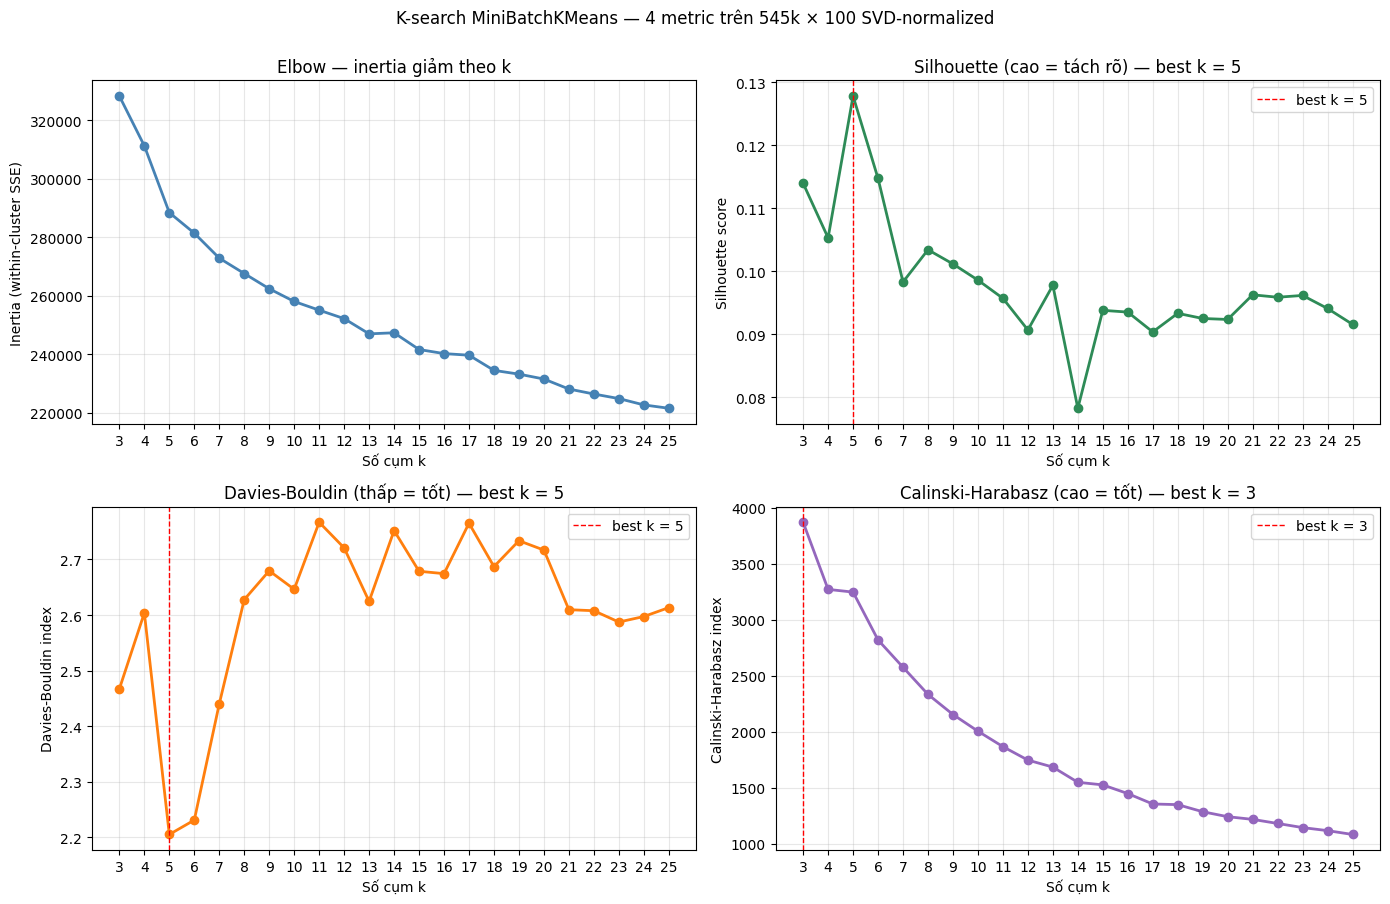

Đã lưu: D:\Documents\School\Ki_6\KHDL\09 - Dự đoán mức lương kỳ vọng dựa trên bản mô tả công việc (Job Description)\figures\clustering_k_search.png

→ Best k theo silhouette grid: 5. Sẽ chạy Optuna fine-tune ở Section 2.5.


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
ks = results_df['k']

ax = axes[0, 0]
ax.plot(ks, results_df['inertia'], 'o-', color='steelblue', lw=2)
ax.set_xlabel('Số cụm k')
ax.set_ylabel('Inertia (within-cluster SSE)')
ax.set_title('Elbow — inertia giảm theo k')
ax.set_xticks(ks)
ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(ks, results_df['silhouette'], 'o-', color='seagreen', lw=2)
best_sil_k = int(results_df.loc[results_df['silhouette'].idxmax(), 'k'])
ax.axvline(best_sil_k, color='red', linestyle='--', lw=1, label=f'best k = {best_sil_k}')
ax.set_xlabel('Số cụm k')
ax.set_ylabel('Silhouette score')
ax.set_title(f'Silhouette (cao = tách rõ) — best k = {best_sil_k}')
ax.set_xticks(ks)
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.plot(ks, results_df['davies_bouldin'], 'o-', color='tab:orange', lw=2)
best_db_k = int(results_df.loc[results_df['davies_bouldin'].idxmin(), 'k'])
ax.axvline(best_db_k, color='red', linestyle='--', lw=1, label=f'best k = {best_db_k}')
ax.set_xlabel('Số cụm k')
ax.set_ylabel('Davies-Bouldin index')
ax.set_title(f'Davies-Bouldin (thấp = tốt) — best k = {best_db_k}')
ax.set_xticks(ks)
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.plot(ks, results_df['calinski_harabasz'], 'o-', color='tab:purple', lw=2)
best_ch_k = int(results_df.loc[results_df['calinski_harabasz'].idxmax(), 'k'])
ax.axvline(best_ch_k, color='red', linestyle='--', lw=1, label=f'best k = {best_ch_k}')
ax.set_xlabel('Số cụm k')
ax.set_ylabel('Calinski-Harabasz index')
ax.set_title(f'Calinski-Harabasz (cao = tốt) — best k = {best_ch_k}')
ax.set_xticks(ks)
ax.legend()
ax.grid(alpha=0.3)

plt.suptitle('K-search MiniBatchKMeans — 4 metric trên 545k × 100 SVD-normalized', y=1.00)
plt.tight_layout()
plt.savefig(FIG_DIR / 'clustering_k_search.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Đã lưu: {FIG_DIR / 'clustering_k_search.png'}")

K_SIL_BEST = best_sil_k
print(f"\n→ Best k theo silhouette grid: {K_SIL_BEST}. Sẽ chạy Optuna fine-tune ở Section 2.5.")

## 2.5. Optuna study — fine-tune `(k, init, whitening_strength)`

Grid search ở Section 2 chỉ tune `k` với init mặc định `k-means++`. Optuna mở rộng search space:
- `k`: int ∈ [3, 25]
- `init`: 'k-means++' hoặc 'random'
- `whitening_strength`: float ∈ [0.0, 1.0] — chia mỗi cột SVD cho `std^whitening`. Whitening=1.0 chuẩn hoá toàn bộ, =0.0 không whitening.

**Objective**: silhouette score (max) trên sample 25k. 30 trials TPE Bayesian.

In [5]:
import time

OPTUNA_SAMPLE = 25_000

def objective(trial):
    k = trial.suggest_int('k', 3, 25)
    init = trial.suggest_categorical('init', ['k-means++', 'random'])
    whitening = trial.suggest_float('whitening_strength', 0.0, 1.0)

    X = X_train_svd_n
    if whitening > 0.01:
        std = X.std(axis=0) + 1e-8
        X = X / (std ** whitening)

    km = MiniBatchKMeans(n_clusters=k, init=init, batch_size=4096,
                         n_init=3, random_state=RANDOM_STATE, max_iter=100)
    labels = km.fit_predict(X)

    rng = np.random.RandomState(RANDOM_STATE)
    idx = rng.choice(len(labels), OPTUNA_SAMPLE, replace=False)
    return silhouette_score(X[idx], labels[idx], random_state=RANDOM_STATE)


print(f"Running Optuna study ({OPTUNA_N_TRIALS} trials, TPE sampler)...")
t0 = time.time()
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    study_name='kmeans_clustering',
)
study.optimize(objective, n_trials=OPTUNA_N_TRIALS, show_progress_bar=False)
print(f"  Done in {time.time()-t0:.1f}s")

print(f"\nBest trial:")
print(f"  silhouette = {study.best_value:+.4f}")
print(f"  params     = {study.best_params}")

# So sánh Optuna best vs grid best → chọn cái có silhouette cao hơn
grid_best_sil = float(results_df['silhouette'].max())
optuna_best_sil = float(study.best_value)

if grid_best_sil >= optuna_best_sil:
    K_FINAL = K_SIL_BEST
    BEST_INIT = 'k-means++'
    BEST_WHITENING = 0.0
    print(f"\n→ GRID WINS: k={K_FINAL}, sil={grid_best_sil:+.4f} "
          f"(Optuna best: k={study.best_params['k']}, sil={optuna_best_sil:+.4f})")
else:
    K_FINAL = study.best_params['k']
    BEST_INIT = study.best_params['init']
    BEST_WHITENING = study.best_params['whitening_strength']
    print(f"\n→ OPTUNA WINS: k={K_FINAL}, init={BEST_INIT}, "
          f"whitening={BEST_WHITENING:.3f}, sil={optuna_best_sil:+.4f}")

Running Optuna study (30 trials, TPE sampler)...


  Done in 210.3s

Best trial:
  silhouette = +0.0959
  params     = {'k': 21, 'init': 'k-means++', 'whitening_strength': 0.004667770139345424}

→ GRID WINS: k=5, sil=+0.1278 (Optuna best: k=21, sil=+0.0959)


### Trực quan — Optuna optimization history

Track silhouette qua các trial. Đường xanh = best so far, chấm = trial cụ thể.

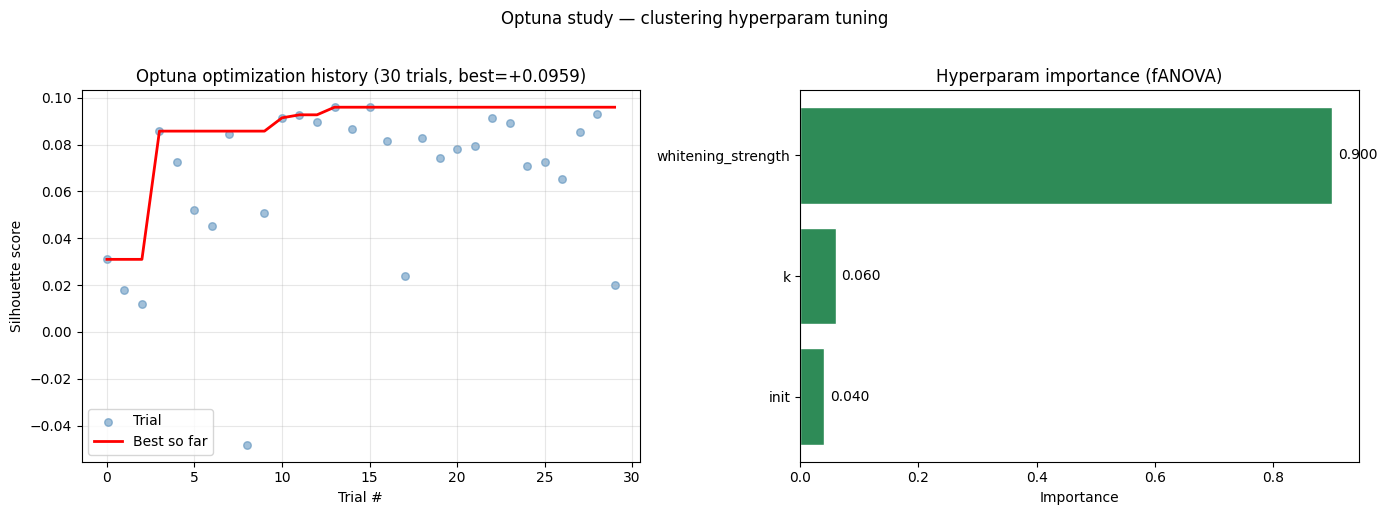

Đã lưu: D:\Documents\School\Ki_6\KHDL\09 - Dự đoán mức lương kỳ vọng dựa trên bản mô tả công việc (Job Description)\figures\clustering_optuna_history.png


In [6]:
trials_df = study.trials_dataframe()
trials_df = trials_df[trials_df['state'] == 'COMPLETE'].copy()
trials_df['best_so_far'] = trials_df['value'].cummax()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Optimization history
ax = axes[0]
ax.scatter(trials_df['number'], trials_df['value'], s=30, alpha=0.5, color='steelblue',
           label='Trial')
ax.plot(trials_df['number'], trials_df['best_so_far'], color='red', lw=2, label='Best so far')
ax.set_xlabel('Trial #')
ax.set_ylabel('Silhouette score')
ax.set_title(f'Optuna optimization history ({OPTUNA_N_TRIALS} trials, '
             f'best={study.best_value:+.4f})')
ax.legend()
ax.grid(alpha=0.3)

# Param importance (nếu có nhiều enough trials)
ax = axes[1]
try:
    importance = optuna.importance.get_param_importances(study)
    params_list = list(importance.keys())
    vals = list(importance.values())
    y_pos = np.arange(len(params_list))[::-1]
    ax.barh(y_pos, vals, color='seagreen', edgecolor='white')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(params_list)
    ax.set_xlabel('Importance')
    ax.set_title('Hyperparam importance (fANOVA)')
    for i, v in enumerate(vals):
        ax.text(v + 0.01, y_pos[i], f'{v:.3f}', va='center', fontsize=10)
except Exception as e:
    ax.text(0.5, 0.5, f"Param importance không tính được:\n{e}",
            ha='center', va='center', transform=ax.transAxes)

plt.suptitle('Optuna study — clustering hyperparam tuning', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'clustering_optuna_history.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Đã lưu: {FIG_DIR / 'clustering_optuna_history.png'}")

## 3. Fit final MiniBatchKMeans với K_FINAL

Fit lại với `K_FINAL` đã chọn ở Section 2, dùng `n_init=5`. Predict labels cho cả train + test.

In [7]:
print(f"Fitting final MiniBatchKMeans với Optuna-best params:")
print(f"  k={K_FINAL}, init={BEST_INIT}, whitening_strength={BEST_WHITENING:.3f}")

# Apply whitening nếu Optuna chọn
X_train_fit = X_train_svd_n.copy()
X_test_fit = X_test_svd_n.copy()
if BEST_WHITENING > 0.01:
    std = X_train_fit.std(axis=0) + 1e-8
    X_train_fit = X_train_fit / (std ** BEST_WHITENING)
    X_test_fit = X_test_fit / (std ** BEST_WHITENING)

import time
t0 = time.time()
kmeans_final = MiniBatchKMeans(n_clusters=K_FINAL, init=BEST_INIT,
                               batch_size=4096, max_iter=300, n_init=5,
                               random_state=RANDOM_STATE)
labels_train = kmeans_final.fit_predict(X_train_fit)
labels_test = kmeans_final.predict(X_test_fit)
print(f"  Fit time: {time.time()-t0:.1f}s")
print(f"  Final inertia: {kmeans_final.inertia_:.0f}")

# Recompute metrics trên ma trận final (whitened nếu có)
rng = np.random.RandomState(RANDOM_STATE)
idx = rng.choice(len(labels_train), METRIC_SAMPLE_SIZE, replace=False)
final_sil = silhouette_score(X_train_fit[idx], labels_train[idx], random_state=RANDOM_STATE)
final_db = davies_bouldin_score(X_train_fit[idx], labels_train[idx])
final_ch = calinski_harabasz_score(X_train_fit[idx], labels_train[idx])
print(f"\nFinal metrics (sample {METRIC_SAMPLE_SIZE:,}):")
print(f"  Silhouette        : {final_sil:+.4f}")
print(f"  Davies-Bouldin    : {final_db:.3f}")
print(f"  Calinski-Harabasz : {final_ch:.0f}")

sizes_train = Counter(labels_train.tolist())
sizes_test = Counter(labels_test.tolist())

print(f"\nCluster sizes (train):")
for c in sorted(sizes_train.keys()):
    pct = sizes_train[c] / len(labels_train) * 100
    bar = '█' * int(pct / 2)
    print(f"  cluster {c:>2}: {sizes_train[c]:>7,} ({pct:5.2f}%) {bar}")

print(f"\nCluster sizes (test):")
for c in sorted(sizes_test.keys()):
    pct = sizes_test[c] / len(labels_test) * 100
    print(f"  cluster {c:>2}: {sizes_test[c]:>6,} ({pct:5.2f}%)")

Fitting final MiniBatchKMeans với Optuna-best params:
  k=5, init=k-means++, whitening_strength=0.000


  Fit time: 0.5s
  Final inertia: 288400



Final metrics (sample 30,000):
  Silhouette        : +0.1279
  Davies-Bouldin    : 2.206
  Calinski-Harabasz : 3249

Cluster sizes (train):
  cluster  0: 117,542 (21.55%) ██████████
  cluster  1: 156,144 (28.63%) ██████████████
  cluster  2: 108,535 (19.90%) █████████
  cluster  3: 133,759 (24.52%) ████████████
  cluster  4:  29,500 ( 5.41%) ██

Cluster sizes (test):
  cluster  0: 13,080 (21.58%)
  cluster  1: 17,067 (28.16%)
  cluster  2: 12,214 (20.15%)
  cluster  3: 15,011 (24.77%)
  cluster  4:  3,234 ( 5.34%)


## 4. So sánh với GaussianMixture (BIC/AIC)

GMM cho **soft clustering** (mỗi điểm có probability vào mỗi cluster). BIC/AIC giúp chọn k tự động: **thấp = tốt**.

GMM full data tốn thời gian → fit trên sample 30k để scan k ∈ [3, 15]. Mục đích: so sánh thuật toán với MiniBatchKMeans, không thay thế.

In [8]:
print(f"Sampling {GMM_SAMPLE_SIZE:,} rows cho GMM fit...")
rng = np.random.RandomState(RANDOM_STATE)
gmm_idx = rng.choice(len(X_train_svd_n), GMM_SAMPLE_SIZE, replace=False)
X_gmm = X_train_svd_n[gmm_idx]

gmm_results = []
for k in GMM_K_RANGE:
    t0 = time.time()
    gmm = GaussianMixture(n_components=k, random_state=RANDOM_STATE,
                          covariance_type='diag', max_iter=100, n_init=1)
    gmm.fit(X_gmm)
    bic = gmm.bic(X_gmm)
    aic = gmm.aic(X_gmm)
    elapsed = time.time() - t0
    gmm_results.append({'k': k, 'bic': bic, 'aic': aic, 'fit_time_sec': round(elapsed, 1)})
    print(f"  k={k:>2} | BIC={bic:>12.0f} | AIC={aic:>12.0f} | {elapsed:.1f}s")

gmm_df = pd.DataFrame(gmm_results)
gmm_df.to_csv(MODELS / 'gmm_bic_aic.csv', index=False)

best_bic_k = int(gmm_df.loc[gmm_df['bic'].idxmin(), 'k'])
best_aic_k = int(gmm_df.loc[gmm_df['aic'].idxmin(), 'k'])
print(f"\nGMM best k: BIC={best_bic_k}, AIC={best_aic_k}")
print(f"(So sánh với MiniBatchKMeans best silhouette k = {K_FINAL})")

Sampling 30,000 rows cho GMM fit...


  k= 3 | BIC=   -17095942 | AIC=   -17103436 | 0.8s


  k= 4 | BIC=   -17273428 | AIC=   -17283424 | 0.8s


  k= 5 | BIC=   -17323148 | AIC=   -17335644 | 0.7s


  k= 6 | BIC=   -17444620 | AIC=   -17459618 | 0.8s


...

  k=11 | BIC=   -17712143 | AIC=   -17739645 | 1.0s


  k=12 | BIC=   -17747831 | AIC=   -17777834 | 1.0s


  k=13 | BIC=   -17807337 | AIC=   -17839841 | 1.2s


  k=14 | BIC=   -17818470 | AIC=   -17853476 | 1.2s


  k=15 | BIC=   -17808186 | AIC=   -17845692 | 1.1s

GMM best k: BIC=14, AIC=14
(So sánh với MiniBatchKMeans best silhouette k = 5)


### Trực quan — GMM BIC/AIC theo k

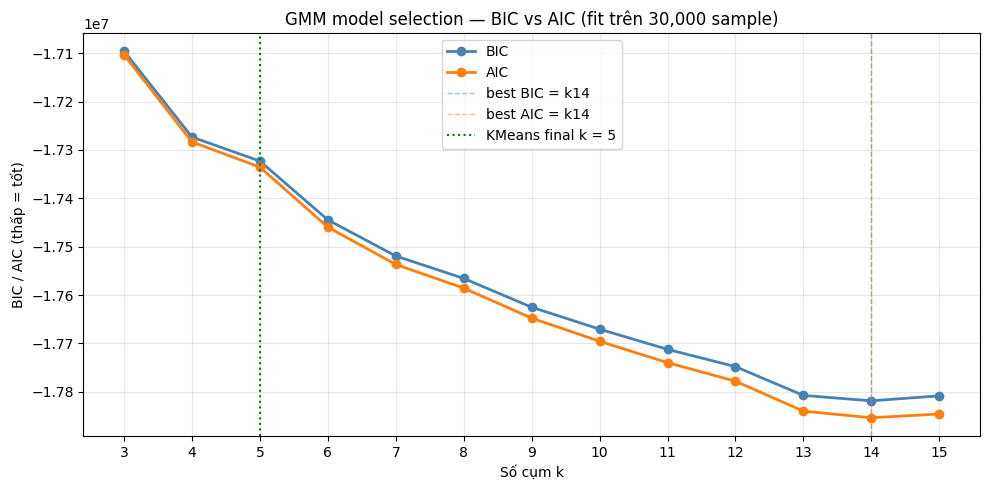

Đã lưu: D:\Documents\School\Ki_6\KHDL\09 - Dự đoán mức lương kỳ vọng dựa trên bản mô tả công việc (Job Description)\figures\clustering_gmm_bic_aic.png


In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(gmm_df['k'], gmm_df['bic'], 'o-', color='steelblue', lw=2, label='BIC')
ax.plot(gmm_df['k'], gmm_df['aic'], 'o-', color='tab:orange', lw=2, label='AIC')
ax.axvline(best_bic_k, color='steelblue', linestyle='--', lw=1, alpha=0.5,
           label=f'best BIC = k{best_bic_k}')
ax.axvline(best_aic_k, color='tab:orange', linestyle='--', lw=1, alpha=0.5,
           label=f'best AIC = k{best_aic_k}')
ax.axvline(K_FINAL, color='green', linestyle=':', lw=1.5,
           label=f'KMeans final k = {K_FINAL}')
ax.set_xlabel('Số cụm k')
ax.set_ylabel('BIC / AIC (thấp = tốt)')
ax.set_title(f'GMM model selection — BIC vs AIC (fit trên {GMM_SAMPLE_SIZE:,} sample)')
ax.set_xticks(gmm_df['k'])
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'clustering_gmm_bic_aic.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Đã lưu: {FIG_DIR / 'clustering_gmm_bic_aic.png'}")

## 5. Mô tả cụm — cluster profiling

Với mỗi cluster k, tính (chunked read clean_data_train.csv để tránh OOM):
- **Số mẫu** + %
- **Mean/median `salary_mid`** + **mean `years_exp`**
- **Top-3 industries** (multi-label, đếm xuất hiện)
- **Top-1 province**, **top-1 job_position**, **top-1 education_level**
- **Year mode**

Đây là cơ sở để gán nhãn cụm.

In [10]:
cluster_counts = {c: 0 for c in range(K_FINAL)}
cluster_salary = {c: [] for c in range(K_FINAL)}
cluster_years = {c: [] for c in range(K_FINAL)}
cluster_year_dist = {c: Counter() for c in range(K_FINAL)}
cluster_province = {c: Counter() for c in range(K_FINAL)}
cluster_industry = {c: Counter() for c in range(K_FINAL)}
cluster_position = {c: Counter() for c in range(K_FINAL)}
cluster_education = {c: Counter() for c in range(K_FINAL)}

profile_cols = ['salary_mid', 'years_exp', 'year', 'province', 'industries_list',
                'job_position', 'education_level']

print(f"Streaming clean_data_train.csv để aggregate per cluster...")
row_idx = 0
for chunk in pd.read_csv(CLEAN / 'clean_data_train.csv',
                         chunksize=PROFILE_CHUNK, usecols=profile_cols):
    chunk_labels = labels_train[row_idx: row_idx + len(chunk)]
    chunk = chunk.assign(_cluster=chunk_labels)

    for c, grp in chunk.groupby('_cluster'):
        cluster_counts[c] += len(grp)
        sal = grp['salary_mid'].dropna()
        cluster_salary[c].extend(sal.tolist())
        yrs = grp['years_exp'].dropna()
        cluster_years[c].extend(yrs.tolist())
        cluster_year_dist[c].update(grp['year'].tolist())
        cluster_province[c].update(grp['province'].tolist())
        cluster_position[c].update(grp['job_position'].tolist())
        cluster_education[c].update(grp['education_level'].tolist())
        for s in grp['industries_list']:
            if isinstance(s, str) and s:
                for ind in s.split('|'):
                    if ind:
                        cluster_industry[c][ind] += 1

    row_idx += len(chunk)
    sys.stdout.write(f"\r  processed {row_idx:>9,}/{len(labels_train):,} "
                     f"({row_idx*100/len(labels_train):5.1f}%)")
    sys.stdout.flush()
print()

profile_rows = []
total = sum(cluster_counts.values())
for c in range(K_FINAL):
    sal = np.array(cluster_salary[c]) if cluster_salary[c] else np.array([])
    yrs = np.array(cluster_years[c]) if cluster_years[c] else np.array([])
    profile_rows.append({
        'cluster': c,
        'n': cluster_counts[c],
        'pct': round(cluster_counts[c] / total * 100, 2),
        'mean_salary': round(float(sal.mean()), 2) if len(sal) else np.nan,
        'median_salary': round(float(np.median(sal)), 2) if len(sal) else np.nan,
        'mean_years_exp': round(float(yrs.mean()), 2) if len(yrs) else np.nan,
        'top_industry_1': cluster_industry[c].most_common(1)[0][0] if cluster_industry[c] else '',
        'top_industry_2': (cluster_industry[c].most_common(2)[1][0]
                           if len(cluster_industry[c]) > 1 else ''),
        'top_industry_3': (cluster_industry[c].most_common(3)[2][0]
                           if len(cluster_industry[c]) > 2 else ''),
        'top_province': cluster_province[c].most_common(1)[0][0] if cluster_province[c] else '',
        'top_position': cluster_position[c].most_common(1)[0][0] if cluster_position[c] else '',
        'top_education': cluster_education[c].most_common(1)[0][0] if cluster_education[c] else '',
        'year_mode': cluster_year_dist[c].most_common(1)[0][0] if cluster_year_dist[c] else '',
    })

profile_df = pd.DataFrame(profile_rows)
profile_df.to_csv(MODELS / 'cluster_profiles.csv', index=False, encoding='utf-8-sig')
print(f"\nĐã lưu: {MODELS / 'cluster_profiles.csv'}")
print("\nCluster profile:")
print(profile_df.to_string(index=False))

Streaming clean_data_train.csv để aggregate per cluster...


  processed    50,000/545,480 (  9.2%)

  processed   100,000/545,480 ( 18.3%)

  processed   150,000/545,480 ( 27.5%)

  processed   200,000/545,480 ( 36.7%)

...

  processed   400,000/545,480 ( 73.3%)

  processed   450,000/545,480 ( 82.5%)

  processed   500,000/545,480 ( 91.7%)

  processed   545,480/545,480 (100.0%)



Đã lưu: D:\Documents\School\Ki_6\KHDL\09 - Dự đoán mức lương kỳ vọng dựa trên bản mô tả công việc (Job Description)\models\cluster_profiles.csv

Cluster profile:
 cluster      n   pct  mean_salary  median_salary  mean_years_exp        top_industry_1        top_industry_2                 top_industry_3 top_province top_position top_education  year_mode
       0 117542 21.55         9.84           10.0            1.37   Chăm sóc khách hàng    Lao động phổ thông          Bán hàng - Kinh doanh  Hồ Chí Minh    nhân viên         không       2025
       1 156144 28.63        10.37           10.0            2.18 Bán hàng - Kinh doanh   Chăm sóc khách hàng Khách sạn - Nhà hàng - Du lịch  Hồ Chí Minh    nhân viên      cao đẳng       2022
       2 108535 19.90        22.96           20.0            3.39   Chăm sóc khách hàng Bán hàng - Kinh doanh                       Xây dựng  Hồ Chí Minh    nhân viên         không       2024
       3 133759 24.52        12.00           12.0            3.64   

## 6. Top TF-IDF tokens cho mỗi cluster

Centroid trong sparse X_train (32k chiều): mean TF-IDF rows thuộc cluster k. Top tokens cao nhất = "từ khoá" mô tả cluster, giúp gán nhãn cụm.

In [11]:
N_TOP_TOKENS = 12
feature_names_arr = np.array(feature_names)

tfidf_starts = [meta['groups'][f'tfidf_{c}'][0] for c in meta['text_cols']]
tfidf_ends = [meta['groups'][f'tfidf_{c}'][1] for c in meta['text_cols']]
tfidf_col_start = min(tfidf_starts)
tfidf_col_end = max(tfidf_ends)
tfidf_col_idx = np.arange(tfidf_col_start, tfidf_col_end)
tfidf_names = feature_names_arr[tfidf_col_idx]

print(f"TF-IDF columns: [{tfidf_col_start}, {tfidf_col_end}) → {len(tfidf_col_idx):,} cols\n")

X_train_tfidf = X_train_sp[:, tfidf_col_idx].tocsr()

cluster_top_tokens = {}
for c in range(K_FINAL):
    mask = labels_train == c
    if mask.sum() == 0:
        cluster_top_tokens[c] = []
        continue
    centroid = np.asarray(X_train_tfidf[mask].mean(axis=0)).ravel()
    top_idx = np.argsort(centroid)[-N_TOP_TOKENS:][::-1]
    cluster_top_tokens[c] = [(tfidf_names[i], float(centroid[i])) for i in top_idx]

print(f"Top {N_TOP_TOKENS} TF-IDF tokens mỗi cluster:\n")
for c in range(K_FINAL):
    pct = cluster_counts[c] / sum(cluster_counts.values()) * 100
    print(f"--- Cluster {c} (n={cluster_counts[c]:,}, {pct:.1f}%) ---")
    for tok, val in cluster_top_tokens[c]:
        print(f"  {tok[:70]:70s}  {val:.4f}")
    print()

TF-IDF columns: [202, 25664) → 25,462 cols



Top 12 TF-IDF tokens mỗi cluster:

--- Cluster 0 (n=117,542, 21.5%) ---
  tfidf_job_description__hàng                                             0.0761
  tfidf_job_title__nhân                                                   0.0748
  tfidf_job_title__nhân viên                                              0.0731
  tfidf_job_title__viên                                                   0.0723
  tfidf_job_description__khách                                            0.0664
  tfidf_benefits__việc                                                    0.0620
  tfidf_benefits__lương                                                   0.0610
  tfidf_requirements__tốt                                                 0.0577
  tfidf_requirements__việc                                                0.0550
  tfidf_benefits__thưởng                                                  0.0549
  tfidf_benefits__làm                                                     0.0540
  tfidf_benefits__tháng              

## 7. Gán nhãn cụm — interpretation thủ công

Tự sinh nhãn sơ bộ từ `top_industry + top_position + top_province + mean_salary`. Có thể edit tay `cluster_names.json` sau khi xem profile chi tiết để rút gọn tên cho đẹp (vd. *"IT mid-level HCM"*, *"Manufacturing junior Bắc Bộ"*).

In [12]:
cluster_names = {}
for c in range(K_FINAL):
    top_ind = cluster_industry[c].most_common(1)[0][0] if cluster_industry[c] else 'Khác'
    top_pos = cluster_position[c].most_common(1)[0][0] if cluster_position[c] else 'unknown'
    top_prov = cluster_province[c].most_common(1)[0][0] if cluster_province[c] else 'unknown'
    mean_sal = float(np.array(cluster_salary[c]).mean()) if cluster_salary[c] else 0.0
    cluster_names[c] = f"{top_ind} ({top_pos}, {top_prov}, ~{mean_sal:.0f}tr)"

print("Nhãn cụm tự sinh (auto):")
for c in sorted(cluster_names.keys()):
    print(f"  cluster {c:>2}: {cluster_names[c]}")

(MODELS / 'cluster_names.json').write_text(
    json.dumps({str(c): n for c, n in cluster_names.items()},
               ensure_ascii=False, indent=2),
    encoding='utf-8')
print(f"\nĐã lưu: {MODELS / 'cluster_names.json'}")
print("→ Có thể edit tay file này để đổi nhãn cho gọn.")

Nhãn cụm tự sinh (auto):
  cluster  0: Chăm sóc khách hàng (nhân viên, Hồ Chí Minh, ~10tr)
  cluster  1: Bán hàng - Kinh doanh (nhân viên, Hồ Chí Minh, ~10tr)
  cluster  2: Chăm sóc khách hàng (nhân viên, Hồ Chí Minh, ~23tr)
  cluster  3: Kế toán (nhân viên, Hồ Chí Minh, ~12tr)
  cluster  4: Other (nhân viên, Hồ Chí Minh, ~0tr)

Đã lưu: D:\Documents\School\Ki_6\KHDL\09 - Dự đoán mức lương kỳ vọng dựa trên bản mô tả công việc (Job Description)\models\cluster_names.json
→ Có thể edit tay file này để đổi nhãn cho gọn.


## 8. Visualization — t-SNE 2D projection

t-SNE giảm SVD-100 chiều xuống 2D để trực quan. Vì t-SNE O(n²), dùng **stratified sample 8k** (~`8k/K_FINAL` row/cluster đảm bảo mọi cluster đều xuất hiện trên plot).

Stratified sampling 8,000 rows (1600/cluster) cho t-SNE...
t-SNE input: (8000, 150)


  Done in 13.5s


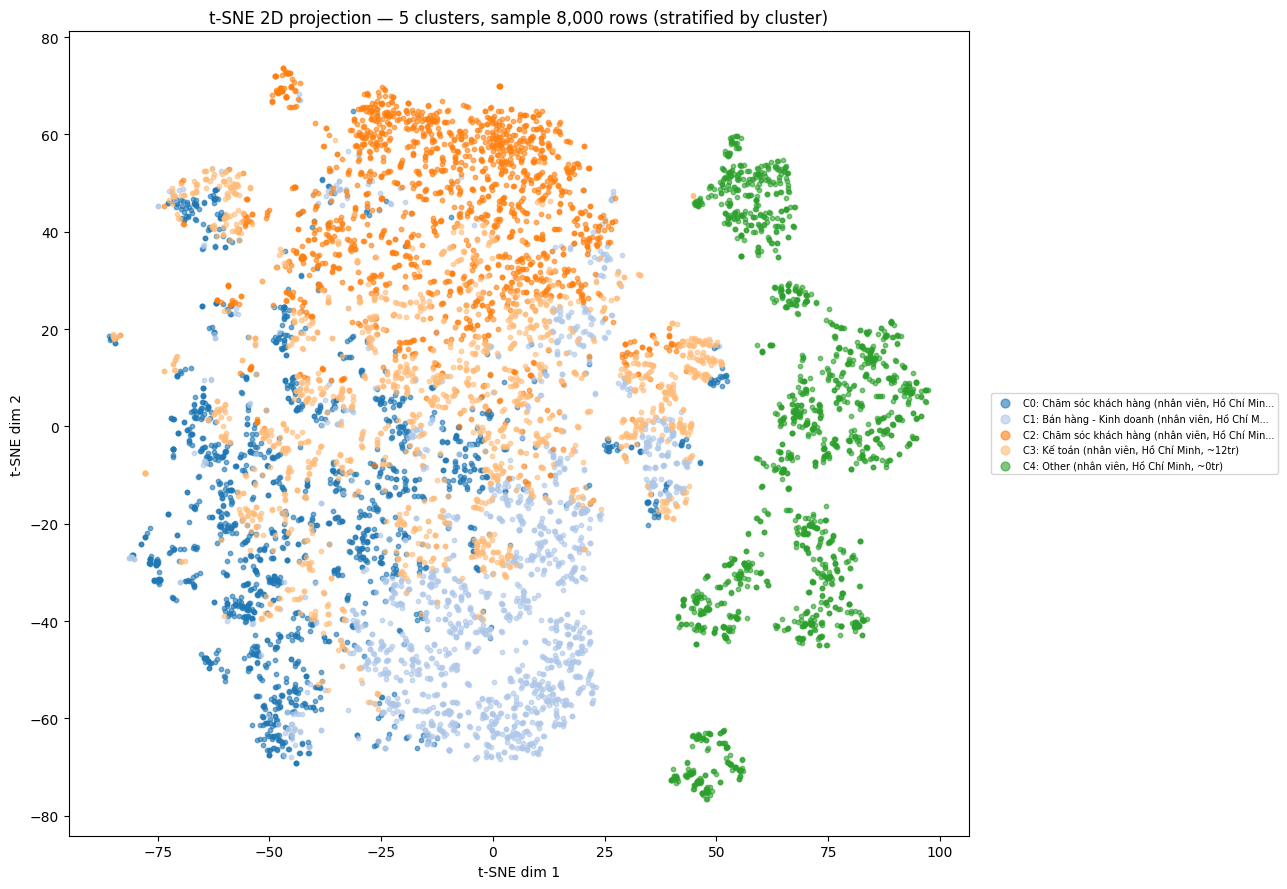

Đã lưu: D:\Documents\School\Ki_6\KHDL\09 - Dự đoán mức lương kỳ vọng dựa trên bản mô tả công việc (Job Description)\figures\clustering_tsne_2d.png


In [13]:
per_cluster = TSNE_SAMPLE_SIZE // K_FINAL
print(f"Stratified sampling {TSNE_SAMPLE_SIZE:,} rows ({per_cluster}/cluster) cho t-SNE...")
rng = np.random.RandomState(RANDOM_STATE)
tsne_idx_list = []
for c in range(K_FINAL):
    cluster_indices = np.where(labels_train == c)[0]
    n_sample = min(per_cluster, len(cluster_indices))
    tsne_idx_list.append(rng.choice(cluster_indices, n_sample, replace=False))
tsne_idx = np.concatenate(tsne_idx_list)
rng.shuffle(tsne_idx)

X_tsne_input = X_train_svd_n[tsne_idx]
y_tsne = labels_train[tsne_idx]
print(f"t-SNE input: {X_tsne_input.shape}")

t0 = time.time()
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000,
            random_state=RANDOM_STATE, init='pca', n_jobs=-1)
X_tsne = tsne.fit_transform(X_tsne_input)
print(f"  Done in {time.time()-t0:.1f}s")

fig, ax = plt.subplots(figsize=(13, 9))
cmap = plt.cm.tab20 if K_FINAL <= 20 else plt.cm.gist_ncar
for c in range(K_FINAL):
    mask = y_tsne == c
    short_name = cluster_names[c]
    if len(short_name) > 45:
        short_name = short_name[:42] + '...'
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               c=[cmap(c % 20)], s=10, alpha=0.6,
               label=f'C{c}: {short_name}')

ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
ax.set_title(f't-SNE 2D projection — {K_FINAL} clusters, sample {len(tsne_idx):,} rows '
             f'(stratified by cluster)')
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=7, markerscale=2)

plt.tight_layout()
plt.savefig(FIG_DIR / 'clustering_tsne_2d.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Đã lưu: {FIG_DIR / 'clustering_tsne_2d.png'}")

## 9. Demo 10 mẫu test (theo yêu cầu template báo cáo)

Random `DEMO_N_TEST=10` mẫu từ test set, predict cluster, hiển thị các trường chính + nhãn cụm.

In [14]:
test_clean = pd.read_csv(CLEAN / 'clean_data_test.csv',
                         usecols=['id', 'salary_min', 'salary_max', 'salary_mid',
                                  'years_exp', 'province', 'industries_list',
                                  'education_level', 'job_position', 'job_title'])
assert len(test_clean) == len(labels_test), \
    f"Mismatch: {len(test_clean)} vs {len(labels_test)}"

rng = np.random.RandomState(RANDOM_STATE)
demo_idx = sorted(rng.choice(len(test_clean), DEMO_N_TEST, replace=False).tolist())

demo_df = test_clean.iloc[demo_idx].copy()
demo_df['cluster'] = labels_test[demo_idx]
demo_df['cluster_name'] = demo_df['cluster'].map(cluster_names)

print(f"=== Demo {DEMO_N_TEST} mẫu test ===\n")
for _, row in demo_df.iterrows():
    print(f"[id={row['id']}] → cluster {row['cluster']}: {row['cluster_name']}")
    print(f"  job_title  : {row['job_title']}")
    if pd.notna(row['salary_mid']):
        print(f"  salary     : {row['salary_min']:.0f}-{row['salary_max']:.0f}M "
              f"(mid={row['salary_mid']:.0f}M)")
    else:
        print(f"  salary     : (missing)")
    yrs = row['years_exp']
    yrs_str = f"{yrs:.1f} năm" if pd.notna(yrs) else "missing"
    print(f"  province   : {row['province']:30s} | years_exp: {yrs_str}")
    print(f"  industries : {row['industries_list']}")
    print(f"  position   : {row['job_position']:30s} | education: {row['education_level']}")
    print()

demo_df.to_csv(MODELS / 'demo_10_test_samples.csv', index=False, encoding='utf-8-sig')
print(f"Đã lưu: {MODELS / 'demo_10_test_samples.csv'}")

=== Demo 10 mẫu test ===

[id=7642] → cluster 4: Other (nhân viên, Hồ Chí Minh, ~0tr)
  job_title  : Trade Operations Manager
  salary     : (missing)
  province   : Hồ Chí Minh                    | years_exp: missing
  industries : Other
  position   : trưởng phòng                   | education: không

[id=57771] → cluster 1: Bán hàng - Kinh doanh (nhân viên, Hồ Chí Minh, ~10tr)
  job_title  : Nhân Viên Kinh Doanh
  salary     : 6-20M (mid=13M)
  province   : Other                          | years_exp: 1.0 năm
  industries : Bán hàng - Kinh doanh
  position   : nhân viên                      | education: không

[id=110580] → cluster 1: Bán hàng - Kinh doanh (nhân viên, Hồ Chí Minh, ~10tr)
  job_title  : Nhân Viên Bán Hàng
  salary     : 10-15M (mid=12M)
  province   : Bình Phước                     | years_exp: 3.0 năm
  industries : Bán hàng - Kinh doanh
  position   : chưa cập nhật                  | education: cao đẳng

[id=291077] → cluster 2: Chăm sóc khách hàng (nhân viên, Hồ Ch

## 10. Lưu artifact

Tổng kết các file output trong `models/`.

In [15]:
joblib.dump(kmeans_final, MODELS / 'kmeans_best.joblib', compress=3)

print(f"Refit GMM với best BIC k={best_bic_k}...")
gmm_best = GaussianMixture(n_components=best_bic_k, random_state=RANDOM_STATE,
                            covariance_type='diag', max_iter=200, n_init=3)
gmm_best.fit(X_gmm)
joblib.dump(gmm_best, MODELS / 'gmm_best.joblib', compress=3)

np.save(MODELS / 'labels_train.npy', labels_train)
np.save(MODELS / 'labels_test.npy', labels_test)

summary = {
    'k_final_kmeans': K_FINAL,
    'best_init': BEST_INIT,
    'best_whitening': BEST_WHITENING,
    'final_metrics': {
        'silhouette': float(final_sil),
        'davies_bouldin': float(final_db),
        'calinski_harabasz': float(final_ch),
    },
    'k_search_best': {
        'silhouette': best_sil_k,
        'davies_bouldin': best_db_k,
        'calinski_harabasz': best_ch_k,
    },
    'gmm_best_k': {'bic': best_bic_k, 'aic': best_aic_k},
    'cluster_sizes_train': {str(c): int(sizes_train[c]) for c in sorted(sizes_train.keys())},
    'cluster_sizes_test': {str(c): int(sizes_test[c]) for c in sorted(sizes_test.keys())},
    'random_state': RANDOM_STATE,
    'svd_n_components': meta['n_features_svd'],
    'svd_variance_kept': meta['svd_explained_variance_ratio_total'],
    'gmm_sample_size': GMM_SAMPLE_SIZE,
    'metric_sample_size': METRIC_SAMPLE_SIZE,
    'tsne_sample_size': TSNE_SAMPLE_SIZE,
}
# Save Optuna study
joblib.dump(study, MODELS / 'optuna_study.joblib', compress=3)

(MODELS / 'clustering_summary.json').write_text(
    json.dumps(summary, indent=2, ensure_ascii=False), encoding='utf-8')

print("\nĐã lưu artifact trong models/:")
for fn in ['kmeans_best.joblib', 'gmm_best.joblib',
           'labels_train.npy', 'labels_test.npy',
           'cluster_profiles.csv', 'cluster_names.json',
           'k_search_metrics.csv', 'gmm_bic_aic.csv',
           'demo_10_test_samples.csv', 'clustering_summary.json']:
    p = MODELS / fn
    if p.exists():
        print(f'  {fn:35s} {p.stat().st_size / 1e6:>7.2f} MB')

Refit GMM với best BIC k=14...



Đã lưu artifact trong models/:
  kmeans_best.joblib                     0.23 MB
  gmm_best.joblib                        0.03 MB
  labels_train.npy                       2.18 MB
  labels_test.npy                        0.24 MB
  cluster_profiles.csv                   0.00 MB
  cluster_names.json                     0.00 MB
  k_search_metrics.csv                   0.00 MB
  gmm_bic_aic.csv                        0.00 MB
  demo_10_test_samples.csv               0.00 MB
  clustering_summary.json                0.00 MB


## 11. Bước tiếp theo (không thuộc code)

Đến đây pipeline 4 stage clustering đã hoàn tất:

| Stage | Notebook | Output chính |
|---|---|---|
| 1 | EDA | Biểu đồ + quyết định cleaning |
| 2 | Cleaning | `clean_data_{train,test}.csv` 17 cột (545k/61k) |
| 3 | Feature Engineering | `X_*.npz` sparse + `X_*_svd.npy` dense 100D |
| 4 | Clustering | `kmeans_best.joblib` + labels + profile + nhãn + demo |

**Việc còn lại (user tự lo):**

- **Edit `models/cluster_names.json`** — sửa nhãn tự động thành tên gọn (vd. *"IT mid HCM"*, *"Sales junior toàn quốc"*).
- **Báo cáo PDF** (15-20 trang theo `Mau tieu luan KHDL_2026.docx`). Dùng các figure đã sinh trong `figures/`:
  - `cleaning_*.png` (4 ảnh) — Đặc tính dữ liệu
  - `fe_*.png` (5 ảnh) — Phương pháp feature engineering
  - `clustering_k_search.png` — Justify số cụm
  - `clustering_gmm_bic_aic.png` — So sánh thuật toán (KMeans vs GMM)
  - `clustering_tsne_2d.png` — Visualization cluster
- **Slide PDF** ≤ 15 phút, tập trung: đặc tính dữ liệu + so sánh thuật toán + diễn giải nhãn cụm.
- **Update README** — hướng dẫn trình tự chạy.
- **In bản cứng báo cáo** + mang theo 2-3 máy phòng sự cố.